## Markov Chain Monte Carlo (MCMC)
### 2026/03/05

Markov Chain Monte Carlo (MCMC) is a sampling method used to efficiently map out a probability distribution, weighted towards the greatest probability.
The Markov chain is formed by the following rules:

1. If $f(x') > f(x)$ : accept
2. If $f(x') < f(x)$ : accept with probabilty $\frac{f(x')}{f(x)}$

These rules effectively mean we:

1. Sample the high density regions
2. Sometimes sample the low density regions

In python we can use the package `emcee` to perform this. In this notebook I will test `emcee` against a polynomial function.

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import minimize, Parameters, Minimizer, create_params, report_fit, conf_interval, printfuncs
import corner

Lets define our underlying test data is a noisy sine wave. 
The task is to find the parameters that best fit this data. Since our test data resembles a sine wave, I will choose my model to be a sine function $y_{model} = a\mathrm{sin}(2\pi x/p)$, with two parameters a (amplitude), and p (period) - the test data is also this but with added noise.

For my application, the noisy test data is my experimental data, the model is my synthetic data.

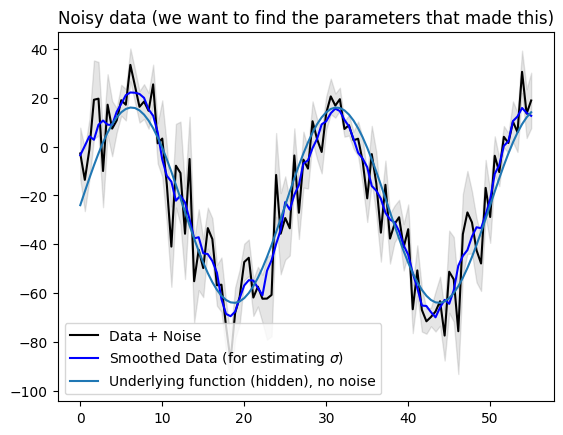

In [69]:
np.random.seed(0)
# Defining test data (experimental data)
def generate_data(a, p, d, xdata, noise=True):
    ydata = a * np.sin(2*np.pi*xdata/p) - np.log10(d) 
    if noise:
        return ydata + + np.random.normal(size=len(xdata), scale=12)
    else:
        return ydata

a = 40
p = 25
d = 1e24
xdata = np.linspace(0, 55, 100)
ydata = generate_data(a, p, d, xdata, noise=True)
ydata_clean = generate_data(a, p, d, xdata, noise=False)

# Standard deviation of our noisy data is obtained using the local variance of the data (around a window of 5 points)
# stddev^2 = 1/(N-1) sum((y - y_smooth)^2)
# 1. Smooth data using moving average with window size 5 points
# 2. Calculate residuals between noisy data and smoothed data (y - ysmooth)^2
# 3. Calculate sum of residuals around window sum((y - ysmooth)^2)
# 4. Divide by number of points in this window minus 1
window = 5
ydata_smooth = np.convolve(ydata, np.ones(window)/window, mode='same')
var = (ydata - ydata_smooth)**2 # residuals of each point with smoothed data
# variance of point is mean of var within window
std2 = np.convolve(var, np.ones(window), mode='same')
count = np.convolve(np.ones_like(ydata), np.ones(window), mode='same')
count = np.maximum(count,2.)
ydata_sigma = np.sqrt(std2/(count-1))

plt.title("Noisy data (we want to find the parameters that made this)")
plt.plot(xdata, ydata, label="Data + Noise", color="black")
plt.plot(xdata, ydata_smooth, label="Smoothed Data (for estimating $\\sigma$)", color="blue")
plt.plot(xdata, ydata_clean, label="Underlying function (hidden), no noise")
plt.fill_between(xdata,ydata-ydata_sigma,ydata+ydata_sigma, color="black", alpha=0.1)
plt.legend()

I define my model (my synthetic data) as:

$$f(x,a,p) = a\ \mathrm{sin}(2 \pi x/p)$$

The fitting procedure I will use is a reduced chi-squared:

$$\chi^2 = \frac{1}{N-M} \Sigma^n_{n=0}\frac{(y_i - y_m(a,p))^2}{\sigma^2}$$

Note my noisy test data does not have a standard deviation $\sigma$ associated with it, though I could define one based on the local variance..

Now lets setup `lmfit` and `emcee`.

`lmfit.emcee` requires a function that returns the log-posterior probability. The log-posterior probability is a sum of the log-prior probability and log-likelihood functions (and I think the posterior is analogous to our objective function - what we want to minimize or maximize). 
- Our log-priors are assumed to be constant (`0 = log(1)`) within the parameter bounds and zero probability outside (`-np.inf = log(0)`)
- Our log-likelihood function is given by the following [(see emcee notes in lmfit docs)](https://lmfit.github.io/lmfit-py/fitting.html#lmfit.minimizer.Minimizer.emcee): 
$$lnp(D|F_{model})=-\frac{1}{2} \Sigma_n [\frac{(y_{model}-y_i)^2}{\sigma^2_i} + ln(2\pi \sigma^2_n)]$$
- The first term is the residual between model and the data, $\sigma_i$ is the data uncertainty.
- This gives $\chi^2$ when summed over all data points.

In [70]:
# Log-likelihood probability for MCMC `emcee`
def lnprob(params, xdata, ydata, ysigma):
    amp = params["amp"]
    period = params["period"]
    d = params["d"]
    y_model = amp * np.sin(2*np.pi*xdata/period) - d
    return -0.5 * np.sum(((y_model - ydata) / ysigma)**2 + np.log(2 * np.pi * ysigma**2))

Setting up our parameters:
- Initial guesses
- Bounds (used in prior)
- Log transforming so we sample in log space

In [71]:
# d is logarithmic, so take log10 to sample in log space
dguess = np.log10(7e23)
dmin = np.log10(1e23)
dmax = np.log10(1e25)

params = Parameters()
params.add_many(("amp", 45, True, 30, 50),
                 ("period", 28, True, 10, 40),
                 ("d", dguess, True, dmin, dmax))


Setting up our `emcee` minimizer

100%|██████████| 300/300 [00:01<00:00, 259.15it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 6;
tau: [27.49445247 35.73291483 20.95100391]
[[Fit Statistics]]
    # fitting method   = emcee
    # function evals   = 30000
    # data points      = 1
    # variables        = 3
    chi-square         = 148810.767
    reduced chi-square = 148810.767
    Akaike info crit   = 17.9104308
    Bayesian info crit = 11.9104308
[[Variables]]
    amp:     40.8500353 +/- 2.31479185 (5.67%) (init = 45)
    period:  24.7439344 +/- 0.95554743 (3.86%) (init = 28)
    d:       23.9822624 +/- 0.56839751 (2.37%) (init = 23.8451)
[[Correlations]] (unreported correlations are < 0.100)
    C(amp, period) = +0.5804
    C(period, d)   = -0.2013


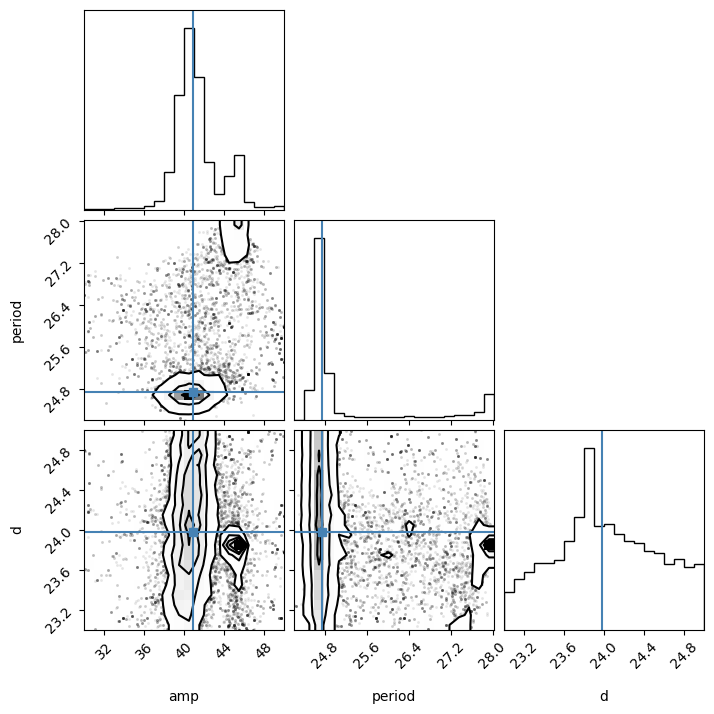

In [72]:
mcmc_minimizer = Minimizer(lnprob, params, fcn_args=(xdata, ydata, ydata_sigma), nan_policy='omit')
mcmc_result = mcmc_minimizer.emcee(steps=300, burn = 0, nwalkers=100, float_behavior="posterior", seed=0)

# compute the fitted model from the best-fit parameters
best_a = mcmc_result.params['amp'].value
best_p = mcmc_result.params['period'].value
best_d = mcmc_result.params['d'].value
fitted_model = best_a * np.sin(2*np.pi*xdata/best_p) - best_d

# show the minimization result
report_fit(mcmc_result)
corner_plot = corner.corner(mcmc_result.flatchain, labels=mcmc_result.var_names,
                           truths=list(mcmc_result.params.valuesdict().values()))

We can visualise what parameters are being tested:

Text(0.5, 0, 'step number')

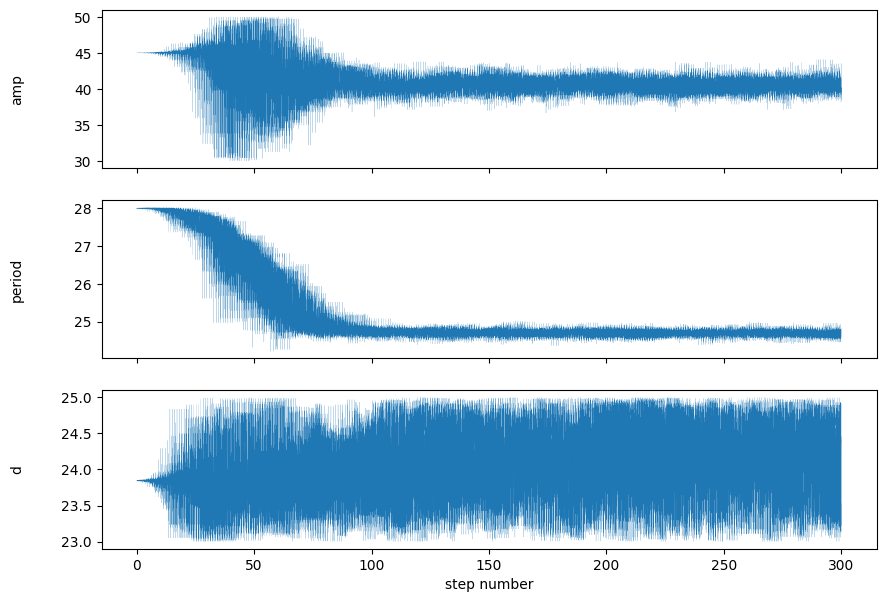

In [73]:
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = mcmc_result.flatchain
labels = ["amp", "period", "d"]
stepnumber = np.arange(len(samples))/100
for i, param in enumerate(samples):
    ax = axes[i]
    ax.plot(stepnumber,samples[param], lw=0.1)
    # ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

- Clearly we need to discard the first 100 samples as these are incorrectly contributing to our posterior distribution. 
- `d` does not have much effect on our model, hence we have a wide spread between 23 and 25 (this was mainly to test log and un-logging) 

Now run again with `burn=100`:

100%|██████████| 300/300 [00:01<00:00, 182.46it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 6;
tau: [27.49445247 35.73291483 20.95100391]
[[Fit Statistics]]
    # fitting method   = emcee
    # function evals   = 30000
    # data points      = 1
    # variables        = 3
    chi-square         = 148627.157
    reduced chi-square = 148627.157
    Akaike info crit   = 17.9091962
    Bayesian info crit = 11.9091962
[[Variables]]
    amp:     40.5566772 +/- 1.05482005 (2.60%) (init = 45)
    period:  24.7022788 +/- 0.08685703 (0.35%) (init = 28)
    d:       24.1262170 +/- 0.60790716 (2.52%) (init = 23.8451)
[[Correlations]] (unreported correlations are < 0.100)
    C(amp, d)      = +0.2563
    C(amp, period) = +0.1155


Text(0.5, 0, 'step number')

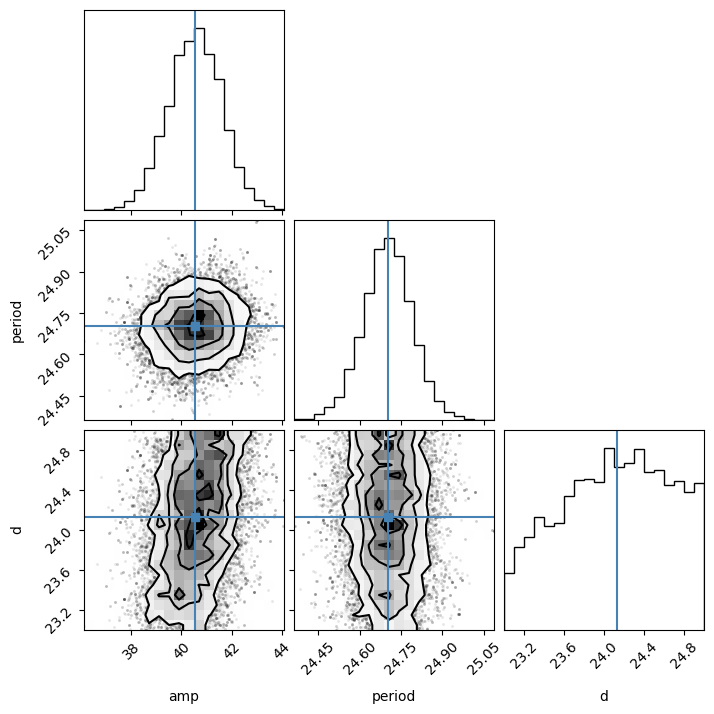

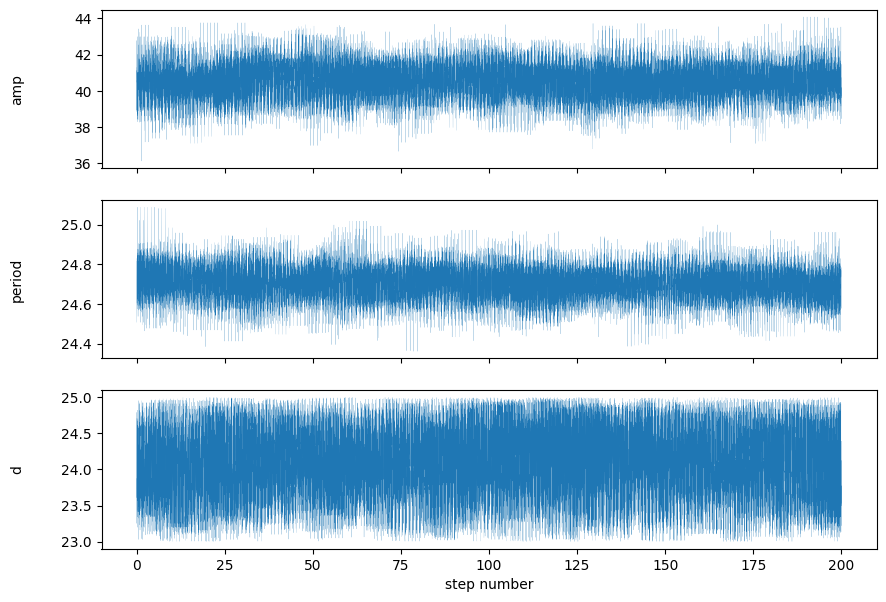

In [ ]:
mcmc_result = mcmc_minimizer.emcee(steps=300, burn = 100, nwalkers=100, float_behavior="posterior", seed=0)

# compute the fitted model from the best-fit parameters
best_a = mcmc_result.params['amp'].value
best_p = mcmc_result.params['period'].value
best_d = mcmc_result.params['d'].value
fitted_model = best_a * np.sin(2*np.pi*xdata/best_p) - best_d

# show the minimization result
report_fit(mcmc_result)

corner_plot = corner.corner(mcmc_result.flatchain, labels=mcmc_result.var_names,
                           truths=list(mcmc_result.params.valuesdict().values()))

fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = mcmc_result.flatchain
labels = ["amp", "period", "d"]
stepnumber = np.arange(len(samples))/100 # dividing by nwalkers to get step number instead of sample number
for i, param in enumerate(samples):
    ax = axes[i]
    ax.plot(stepnumber,samples[param], lw=0.1)
    # ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number")

In [75]:
samples = mcmc_result.flatchain
for param in params:
    result = mcmc_result.params[param].value
    stderr = mcmc_result.params[param].stderr
    print(f"{param}: {result:.2f} +/- {stderr:.2f}")
    lower_bound = result - stderr
    upper_bound = result + stderr
    samples_filtered = samples[(samples[param] > lower_bound) & (samples[param] < upper_bound)]

amp: 40.56 +/- 1.05
period: 24.70 +/- 0.09
d: 24.13 +/- 0.61


In [76]:
y_models = []
for i, row in samples_filtered.iterrows():
    y_model_i = row["amp"] * np.sin(2*np.pi*xdata/row["period"])  - row["d"]
    y_models.append(y_model_i)
y_models = np.array(y_models)

c:\myrepos\mcmc\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


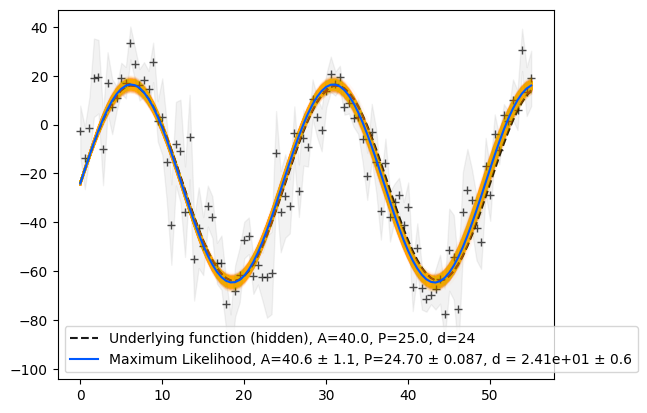

In [81]:
# Plot
fig, ax = plt.subplots()
ax.plot(xdata, ydata, '+', color="black", alpha=0.7)
ax.plot(xdata, ydata_clean, label=f"Underlying function (hidden), A={a:.1f}, P={p:.1f}, d={np.log10(d):.0f}", color="black", ls="--", alpha=0.9)
ax.plot(xdata, y_models.T[:,::3], color="orange", alpha=0.01)
ax.plot(xdata, fitted_model, label=f"Maximum Likelihood, A={best_a:.1f} ± {mcmc_result.params['amp'].stderr:.2g}, P={best_p:.2f} ± {mcmc_result.params['period'].stderr:.2g}, d = {best_d:.2e} ± {mcmc_result.params['d'].stderr:.1f}", color="#0059ff")
ax.fill_between(xdata,ydata-ydata_sigma,ydata+ydata_sigma, color="black", alpha=0.05)

ax.legend()
plt.show()

In [78]:
highest_prob = np.argmax(mcmc_result.lnprob)
hp_loc = np.unravel_index(highest_prob, mcmc_result.lnprob.shape)
mle_soln = mcmc_result.chain[hp_loc]
for i, par in enumerate(params):
    params[par].value = mle_soln[i]

print('\nMaximum Likelihood Estimation from emcee       ')
print('-------------------------------------------------')
print('Parameter  MLE Value   Median Value   Uncertainty')
fmt = '  {:5s}  {:11.5f} {:11.5f}   {:11.5f}'.format
for name, param in params.items():
    print(fmt(name, param.value, mcmc_result.params[name].value,
              mcmc_result.params[name].stderr))



Maximum Likelihood Estimation from emcee       
-------------------------------------------------
Parameter  MLE Value   Median Value   Uncertainty
  amp       40.61575    40.55668       1.05482
  period     24.69952    24.70228       0.08686
  d         24.31130    24.12622       0.60791
